In [6]:
import numpy as np
import matplotlib.pyplot as plt


def read_reg_file(file_path):
    """
    Reads a .reg file, skips comments, and extracts columns into NumPy arrays.
    """
    wavelengths = []
    fluxes = []
    fitted_fluxes = []
    errors = []

    with open(file_path, 'r') as file:
        for line in file:
            # Skip comments
            if line.startswith('#'):
                continue
            
            # Split the line into columns
            parts = line.split()
            if len(parts) >= 4:  # Ensure we have enough columns
                wavelengths.append(float(parts[0]))
                fluxes.append(float(parts[1]))
                fitted_fluxes.append(float(parts[2]))
                errors.append(float(parts[3]))
    
    return np.array(wavelengths), np.array(fluxes), np.array(fitted_fluxes), np.array(errors)

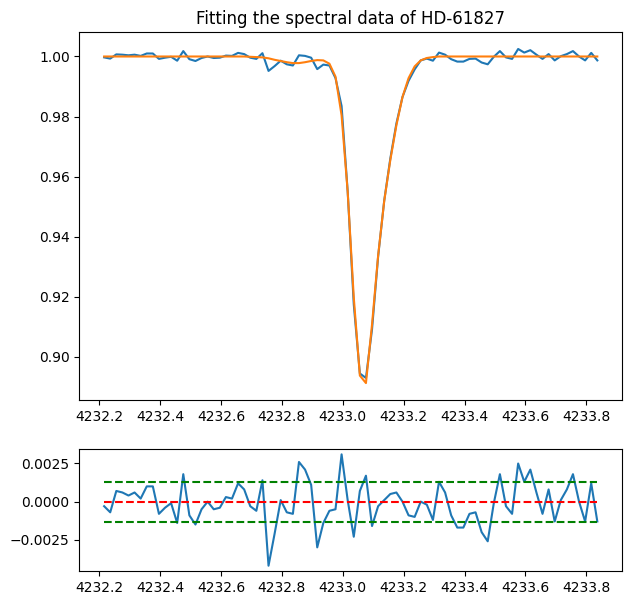

number of parameters: 13
Chi-squared: 82.38461538461497
Reduced Chi-squared: 1.193979933110362
RMS error after fit: 0.0013030452138234822
std_dev from continuum using line-free regions: 0.0013
Log-likelihood: 428.3768
AIC:  -830.7535915502207
BIC:  -799.4662413357854


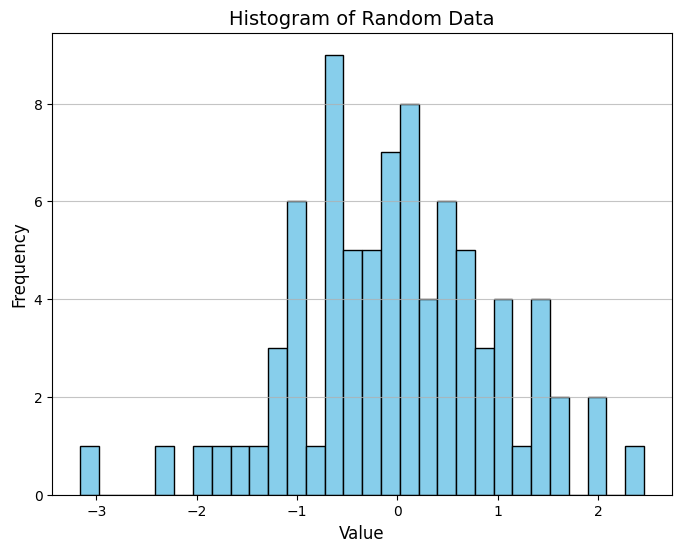

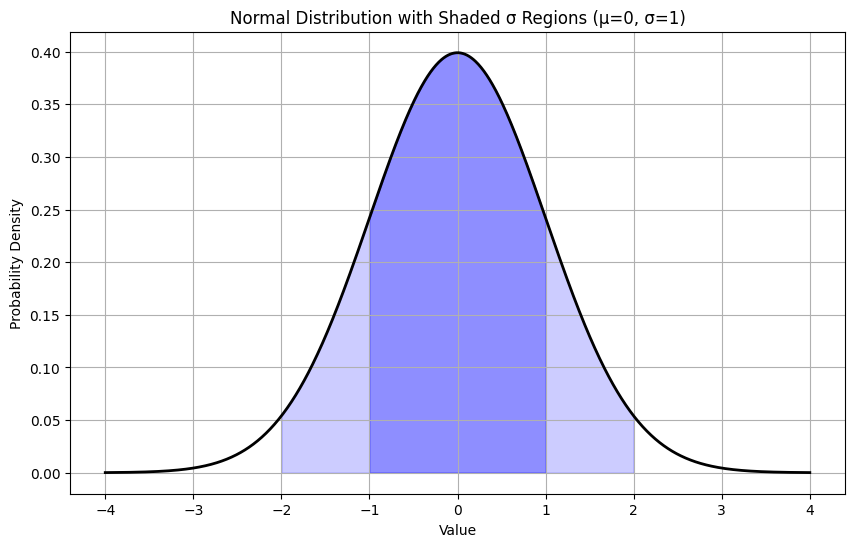

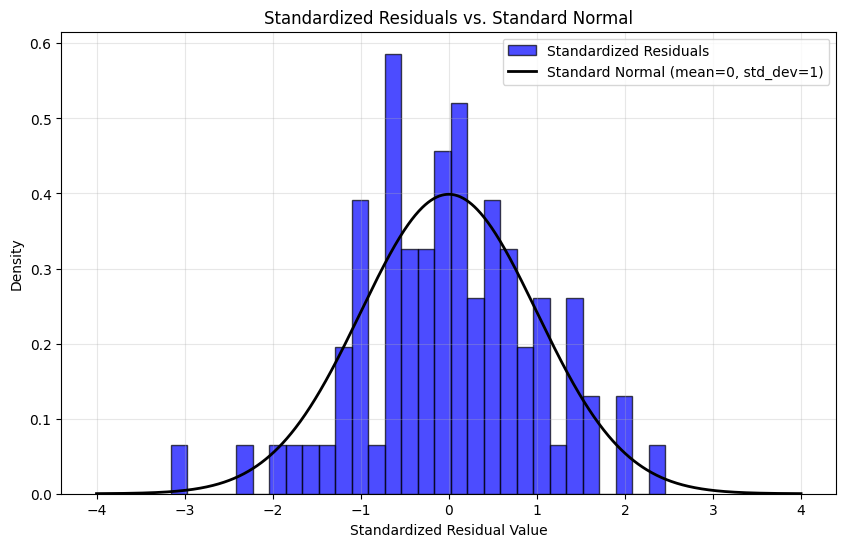

K-S statistic: 0.0602
P-value: 0.9097
p>0.05 hence Fail to reject null hypothesis - residuals appear normally distributed


In [7]:
wavelengths, fluxes, errors,fitted_fluxes = read_reg_file('HD 61827_plot.reg')

# Create a figure with the overall size (10, 8)
fig = plt.figure(figsize=(7, 7))

# Create a GridSpec with 2 rows and 1 column, with different height ratios
grid = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[6, 2])

# Add the first subplot (upper image), which will take up 6/8 of the height
ax1 = fig.add_subplot(grid[0, 0])
ax1.set_title('Fitting the spectral data of HD-61827')
ax1.plot(wavelengths, fluxes, label='data')  
ax1.plot(wavelengths, fitted_fluxes, label='composite fit')




### chisquared calculator.

std_dev = 0.0013  # Assuming a standard deviation for the error
num_params = 13  # Number of parameters in the model (adjust as necessary)
chi_squared = np.sum(((fluxes - fitted_fluxes) / std_dev)**2)
rms_error = np.sqrt((np.sum((fluxes - fitted_fluxes)**2))/len(fluxes))





# Add the second subplot (lower image), which will take up 2/8 of the height
ax2 = fig.add_subplot(grid[1, 0])
# ax2.set_title('Residuals after fitting')
ax2.plot(wavelengths, fluxes - fitted_fluxes)  
ax2.hlines(0, wavelengths.min(), wavelengths.max(), colors='red', linestyles='dashed')
ax2.hlines(rms_error, wavelengths.min(), wavelengths.max(), colors='green', linestyles='dashed')
ax2.hlines(-rms_error, wavelengths.min(), wavelengths.max(), colors='green', linestyles='dashed')
# Show the plot
plt.show()


print('number of parameters:', num_params)
print(f"Chi-squared: {chi_squared}")
print(f"Reduced Chi-squared: {chi_squared / (len(fluxes) - num_params)}")  
print(f"RMS error after fit: {rms_error}")
print(f"std_dev from continuum using line-free regions: {std_dev}")
# print(f"BIC: {chi_squared + num_params * np.log(len(fluxes))}")  # Bayesian Information Criterion
# print(f"AIC: {chi_squared + 2 * num_params}")  # Akaike Information Criterion

# Calculate log-likelihood
num_data_points = len(fluxes)  # Number of data points (e.g.,
log_likelihood = -0.5 * num_data_points * np.log(2 * np.pi) - num_data_points * np.log(std_dev) - 0.5 * chi_squared

# Calculate AIC and BIC
aic = 2 * num_params - 2 * log_likelihood
bic = num_params * np.log(num_data_points) - 2 * log_likelihood

# Print results
# print('Number of parameters:', num_params)
# print(f"Chi-squared: {chi_squared:.4f}")
# print(f"Reduced Chi-squared: {chi_squared / (num_data_points - num_params):.4f}")
print(f"Log-likelihood: {log_likelihood:.4f}")
print(f"AIC: ", aic)
print(f"BIC: ", bic)


#'''''''''''''''''''''''''''''''''''''#############################################''''''''''''''''''''''''''''''''''''''''''


## Next is to check the residuals

Residuals = fluxes - fitted_fluxes
# Create the histogram
plt.figure(figsize=(8, 6))  # Set figure size
plt.hist((Residuals - np.mean(Residuals))/np.std(Residuals), bins=30, color='skyblue', edgecolor='black')
# Add labels and title
plt.xlabel('Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Histogram of Random Data', fontsize=14)
# Add grid lines
plt.grid(axis='y', alpha=0.75)
# Show the plot
plt.show()

from scipy.stats import norm
import matplotlib.pyplot as plt
import numpy as np
mu, sigma = 0, 1
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = norm.pdf(x, mu, sigma)
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'k-', linewidth=2)
# Shade 1σ region
plt.fill_between(x, y, where=((x >= mu-sigma) & (x <= mu+sigma)), color='blue', alpha=0.3)
# Shade 2σ region
plt.fill_between(x, y, where=((x >= mu-2*sigma) & (x <= mu+2*sigma)), color='blue', alpha=0.2)
plt.title(f'Normal Distribution with Shaded σ Regions (μ={mu}, σ={sigma})')
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.grid(True)
plt.show()

# Standardize residuals
std_residuals = (Residuals - np.mean(Residuals)) / np.std(Residuals)
# Now plot histogram vs standard normal
plt.figure(figsize=(10, 6))
plt.hist(std_residuals, bins=30, density=True, 
        alpha=0.7, color='blue', edgecolor='black',
        label='Standardized Residuals')
x = np.linspace(-4, 4, 1000)
plt.plot(x, norm.pdf(x, 0, 1), 'k-', linewidth=2,
         label='Standard Normal (mean=0, std_dev=1)')
plt.xlabel('Standardized Residual Value')
plt.ylabel('Density')
plt.title('Standardized Residuals vs. Standard Normal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()




#'''''''''''''''''''''''''''''''''''''#############################################''''''''''''''''''''''''''''''''''''''''''



# Perform K-S test against standard normal distribution

import numpy as np
from scipy import stats
ks_statistic, p_value = stats.kstest(std_residuals, 'norm')
print(f"K-S statistic: {ks_statistic:.4f}")
print(f"P-value: {p_value:.4f}")
# Interpret the results
alpha = 0.05  # significance level
if p_value > alpha:
    print("p>0.05 hence Fail to reject null hypothesis - residuals appear normally distributed")
else:
    print("p<0.05 hence Reject null hypothesis - residuals do not appear normally distributed")

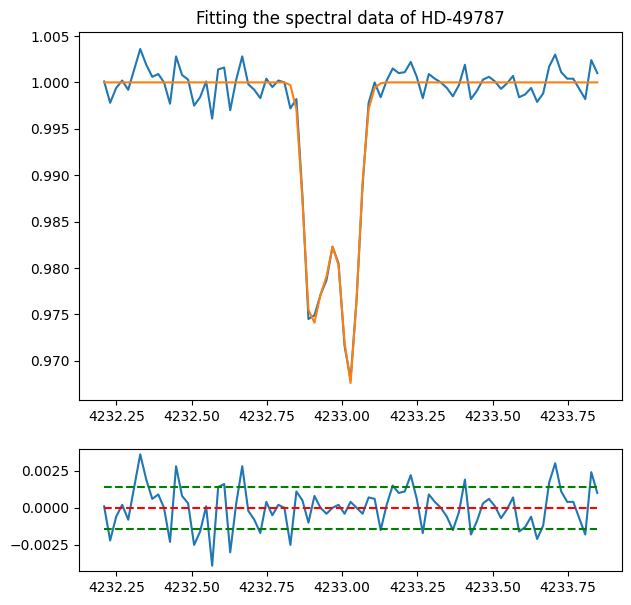

number of parameters: 9
Chi-squared: 71.91999999999959
Reduced Chi-squared: 0.9718918918918863
RMS error after fit: 0.001396294580028461
std_dev from continuum using line-free regions: 0.0015
Log-likelihood: 427.4582
AIC:  -836.9163718531042
BIC:  -815.1468063829349


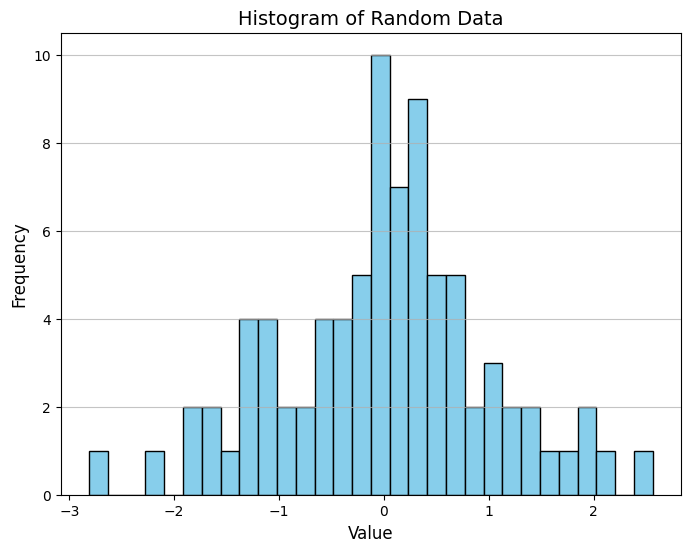

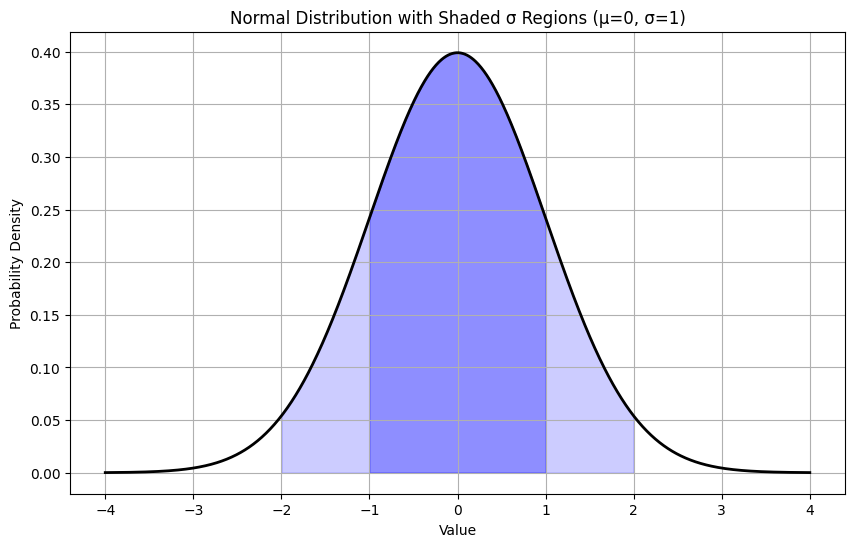

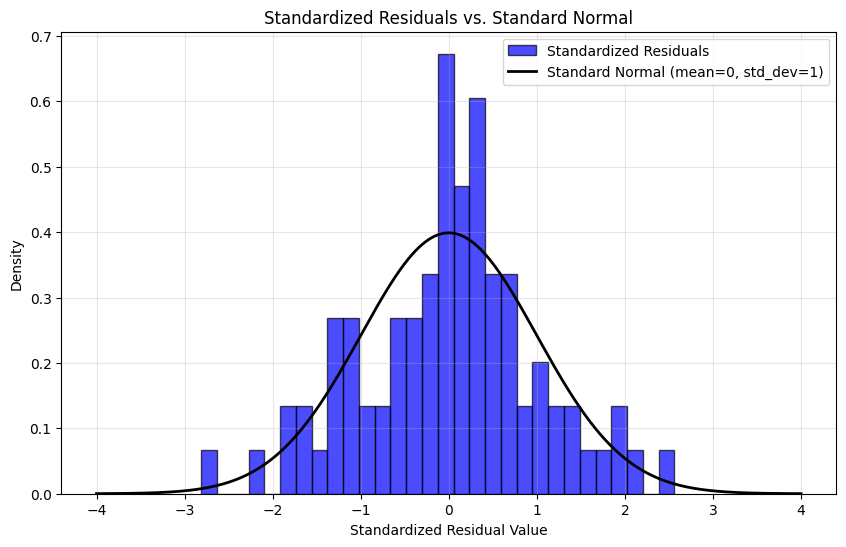

K-S statistic: 0.0955
P-value: 0.4095
p>0.05 hence Fail to reject null hypothesis - residuals appear normally distributed


In [16]:
wavelengths, fluxes, errors,fitted_fluxes = read_reg_file('HD 49787_plot.reg')

# Create a figure with the overall size (10, 8)
fig = plt.figure(figsize=(7, 7))

# Create a GridSpec with 2 rows and 1 column, with different height ratios
grid = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[6, 2])

# Add the first subplot (upper image), which will take up 6/8 of the height
ax1 = fig.add_subplot(grid[0, 0])
ax1.set_title('Fitting the spectral data of HD-49787')
ax1.plot(wavelengths, fluxes, label='data')  
ax1.plot(wavelengths, fitted_fluxes, label='composite fit')




### chisquared calculator.

std_dev = 0.0015  # Assuming a standard deviation for the error
num_params = 9  # Number of parameters in the model (adjust as necessary)
chi_squared = np.sum(((fluxes - fitted_fluxes) / std_dev)**2)
rms_error = np.sqrt((np.sum((fluxes - fitted_fluxes)**2))/len(fluxes))





# Add the second subplot (lower image), which will take up 2/8 of the height
ax2 = fig.add_subplot(grid[1, 0])
# ax2.set_title('Residuals after fitting')
ax2.plot(wavelengths, fluxes - fitted_fluxes)  
ax2.hlines(0, wavelengths.min(), wavelengths.max(), colors='red', linestyles='dashed')
ax2.hlines(rms_error, wavelengths.min(), wavelengths.max(), colors='green', linestyles='dashed')
ax2.hlines(-rms_error, wavelengths.min(), wavelengths.max(), colors='green', linestyles='dashed')
# Show the plot
plt.show()


print('number of parameters:', num_params)
print(f"Chi-squared: {chi_squared}")
print(f"Reduced Chi-squared: {chi_squared / (len(fluxes) - num_params)}")  
print(f"RMS error after fit: {rms_error}")
print(f"std_dev from continuum using line-free regions: {std_dev}")
# print(f"BIC: {chi_squared + num_params * np.log(len(fluxes))}")  # Bayesian Information Criterion
# print(f"AIC: {chi_squared + 2 * num_params}")  # Akaike Information Criterion

# Calculate log-likelihood
num_data_points = len(fluxes)  # Number of data points (e.g.,
log_likelihood = -0.5 * num_data_points * np.log(2 * np.pi) - num_data_points * np.log(std_dev) - 0.5 * chi_squared

# Calculate AIC and BIC
aic = 2 * num_params - 2 * log_likelihood
bic = num_params * np.log(num_data_points) - 2 * log_likelihood

# Print results
# print('Number of parameters:', num_params)
# print(f"Chi-squared: {chi_squared:.4f}")
# print(f"Reduced Chi-squared: {chi_squared / (num_data_points - num_params):.4f}")
print(f"Log-likelihood: {log_likelihood:.4f}")
print(f"AIC: ", aic)
print(f"BIC: ", bic)


#'''''''''''''''''''''''''''''''''''''#############################################''''''''''''''''''''''''''''''''''''''''''


## Next is to check the residuals

Residuals = fluxes - fitted_fluxes
# Create the histogram
plt.figure(figsize=(8, 6))  # Set figure size
plt.hist((Residuals - np.mean(Residuals))/np.std(Residuals), bins=30, color='skyblue', edgecolor='black')
# Add labels and title
plt.xlabel('Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Histogram of Random Data', fontsize=14)
# Add grid lines
plt.grid(axis='y', alpha=0.75)
# Show the plot
plt.show()

from scipy.stats import norm
import matplotlib.pyplot as plt
import numpy as np
mu, sigma = 0, 1
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = norm.pdf(x, mu, sigma)
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'k-', linewidth=2)
# Shade 1σ region
plt.fill_between(x, y, where=((x >= mu-sigma) & (x <= mu+sigma)), color='blue', alpha=0.3)
# Shade 2σ region
plt.fill_between(x, y, where=((x >= mu-2*sigma) & (x <= mu+2*sigma)), color='blue', alpha=0.2)
plt.title(f'Normal Distribution with Shaded σ Regions (μ={mu}, σ={sigma})')
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.grid(True)
plt.show()

# Standardize residuals
std_residuals = (Residuals - np.mean(Residuals)) / np.std(Residuals)
# Now plot histogram vs standard normal
plt.figure(figsize=(10, 6))
plt.hist(std_residuals, bins=30, density=True, 
        alpha=0.7, color='blue', edgecolor='black',
        label='Standardized Residuals')
x = np.linspace(-4, 4, 1000)
plt.plot(x, norm.pdf(x, 0, 1), 'k-', linewidth=2,
         label='Standard Normal (mean=0, std_dev=1)')
plt.xlabel('Standardized Residual Value')
plt.ylabel('Density')
plt.title('Standardized Residuals vs. Standard Normal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()




#'''''''''''''''''''''''''''''''''''''#############################################''''''''''''''''''''''''''''''''''''''''''



# Perform K-S test against standard normal distribution

import numpy as np
from scipy import stats
ks_statistic, p_value = stats.kstest(std_residuals, 'norm')
print(f"K-S statistic: {ks_statistic:.4f}")
print(f"P-value: {p_value:.4f}")
# Interpret the results
alpha = 0.05  # significance level
if p_value > alpha:
    print("p>0.05 hence Fail to reject null hypothesis - residuals appear normally distributed")
else:
    print("p<0.05 hence Reject null hypothesis - residuals do not appear normally distributed")

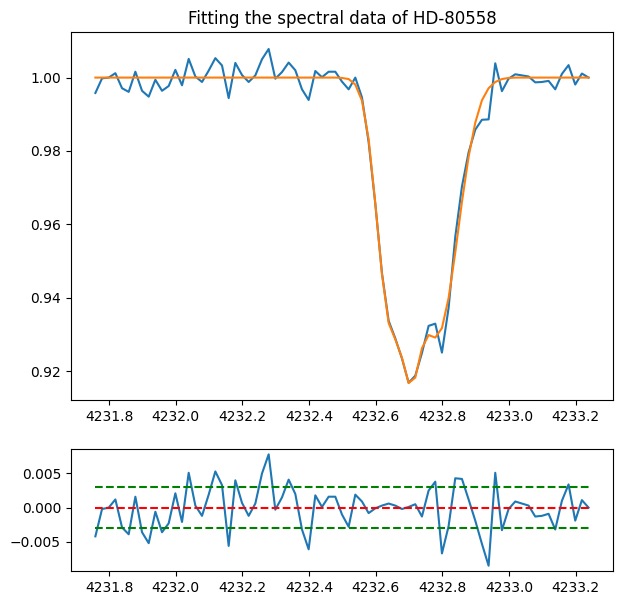

number of parameters: 9
Chi-squared: 95.73525377229096
Reduced Chi-squared: 1.4505341480650145
RMS error after fit: 0.003050486300029338
std_dev from continuum using line-free regions: 0.0027
Log-likelihood: 326.7997
AIC:  -635.5994921427862
BIC:  -614.7420991209594


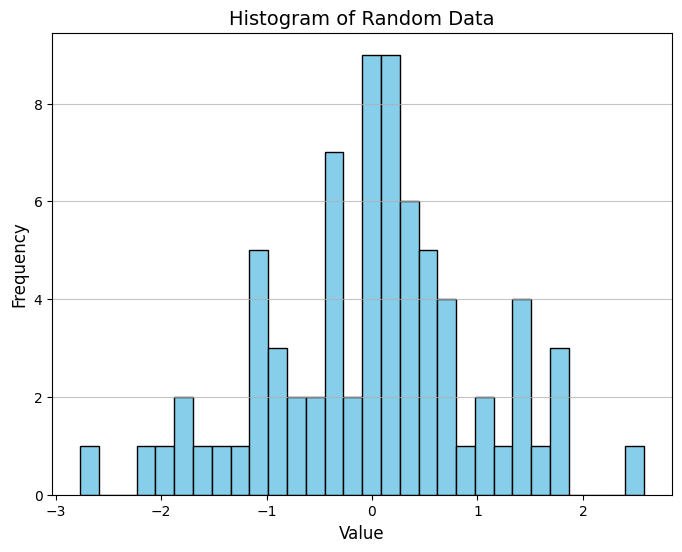

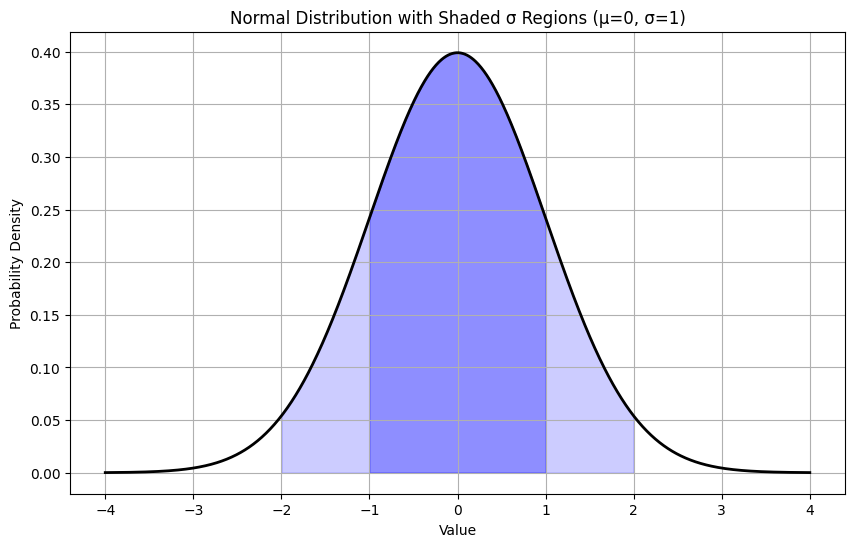

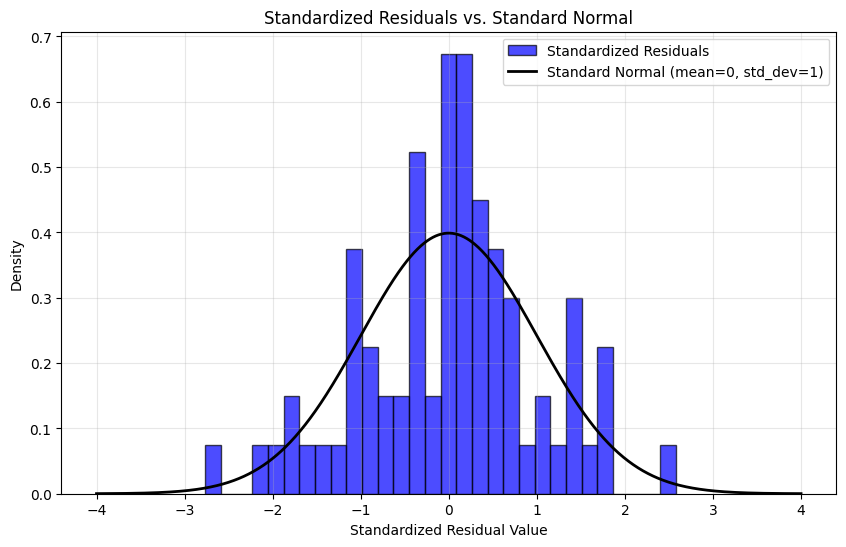

K-S statistic: 0.0827
P-value: 0.6539
p>0.05 hence Fail to reject null hypothesis - residuals appear normally distributed


In [28]:
wavelengths, fluxes, errors,fitted_fluxes = read_reg_file('HD 80558_plot.reg')

# Create a figure with the overall size (10, 8)
fig = plt.figure(figsize=(7, 7))

# Create a GridSpec with 2 rows and 1 column, with different height ratios
grid = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[6, 2])

# Add the first subplot (upper image), which will take up 6/8 of the height
ax1 = fig.add_subplot(grid[0, 0])
ax1.set_title('Fitting the spectral data of HD-80558')
ax1.plot(wavelengths, fluxes, label='data')  
ax1.plot(wavelengths, fitted_fluxes, label='composite fit')




### chisquared calculator.

std_dev = 0.0027  # Assuming a standard deviation for the error
num_params = 9  # Number of parameters in the model (adjust as necessary)
chi_squared = np.sum(((fluxes - fitted_fluxes) / std_dev)**2)
rms_error = np.sqrt((np.sum((fluxes - fitted_fluxes)**2))/len(fluxes))





# Add the second subplot (lower image), which will take up 2/8 of the height
ax2 = fig.add_subplot(grid[1, 0])
# ax2.set_title('Residuals after fitting')
ax2.plot(wavelengths, fluxes - fitted_fluxes)  
ax2.hlines(0, wavelengths.min(), wavelengths.max(), colors='red', linestyles='dashed')
ax2.hlines(rms_error, wavelengths.min(), wavelengths.max(), colors='green', linestyles='dashed')
ax2.hlines(-rms_error, wavelengths.min(), wavelengths.max(), colors='green', linestyles='dashed')
# Show the plot
plt.show()


print('number of parameters:', num_params)
print(f"Chi-squared: {chi_squared}")
print(f"Reduced Chi-squared: {chi_squared / (len(fluxes) - num_params)}")  
print(f"RMS error after fit: {rms_error}")
print(f"std_dev from continuum using line-free regions: {std_dev}")
# print(f"BIC: {chi_squared + num_params * np.log(len(fluxes))}")  # Bayesian Information Criterion
# print(f"AIC: {chi_squared + 2 * num_params}")  # Akaike Information Criterion

# Calculate log-likelihood
num_data_points = len(fluxes)  # Number of data points (e.g.,
log_likelihood = -0.5 * num_data_points * np.log(2 * np.pi) - num_data_points * np.log(std_dev) - 0.5 * chi_squared

# Calculate AIC and BIC
aic = 2 * num_params - 2 * log_likelihood
bic = num_params * np.log(num_data_points) - 2 * log_likelihood

# Print results
# print('Number of parameters:', num_params)
# print(f"Chi-squared: {chi_squared:.4f}")
# print(f"Reduced Chi-squared: {chi_squared / (num_data_points - num_params):.4f}")
print(f"Log-likelihood: {log_likelihood:.4f}")
print(f"AIC: ", aic)
print(f"BIC: ", bic)


#'''''''''''''''''''''''''''''''''''''#############################################''''''''''''''''''''''''''''''''''''''''''


## Next is to check the residuals

Residuals = fluxes - fitted_fluxes
# Create the histogram
plt.figure(figsize=(8, 6))  # Set figure size
plt.hist((Residuals - np.mean(Residuals))/np.std(Residuals), bins=30, color='skyblue', edgecolor='black')
# Add labels and title
plt.xlabel('Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Histogram of Random Data', fontsize=14)
# Add grid lines
plt.grid(axis='y', alpha=0.75)
# Show the plot
plt.show()

from scipy.stats import norm
import matplotlib.pyplot as plt
import numpy as np
mu, sigma = 0, 1
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = norm.pdf(x, mu, sigma)
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'k-', linewidth=2)
# Shade 1σ region
plt.fill_between(x, y, where=((x >= mu-sigma) & (x <= mu+sigma)), color='blue', alpha=0.3)
# Shade 2σ region
plt.fill_between(x, y, where=((x >= mu-2*sigma) & (x <= mu+2*sigma)), color='blue', alpha=0.2)
plt.title(f'Normal Distribution with Shaded σ Regions (μ={mu}, σ={sigma})')
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.grid(True)
plt.show()

# Standardize residuals
std_residuals = (Residuals - np.mean(Residuals)) / np.std(Residuals)
# Now plot histogram vs standard normal
plt.figure(figsize=(10, 6))
plt.hist(std_residuals, bins=30, density=True, 
        alpha=0.7, color='blue', edgecolor='black',
        label='Standardized Residuals')
x = np.linspace(-4, 4, 1000)
plt.plot(x, norm.pdf(x, 0, 1), 'k-', linewidth=2,
         label='Standard Normal (mean=0, std_dev=1)')
plt.xlabel('Standardized Residual Value')
plt.ylabel('Density')
plt.title('Standardized Residuals vs. Standard Normal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()




#'''''''''''''''''''''''''''''''''''''#############################################''''''''''''''''''''''''''''''''''''''''''



# Perform K-S test against standard normal distribution

import numpy as np
from scipy import stats
ks_statistic, p_value = stats.kstest(std_residuals, 'norm')
print(f"K-S statistic: {ks_statistic:.4f}")
print(f"P-value: {p_value:.4f}")
# Interpret the results
alpha = 0.05  # significance level
if p_value > alpha:
    print("p>0.05 hence Fail to reject null hypothesis - residuals appear normally distributed")
else:
    print("p<0.05 hence Reject null hypothesis - residuals do not appear normally distributed")

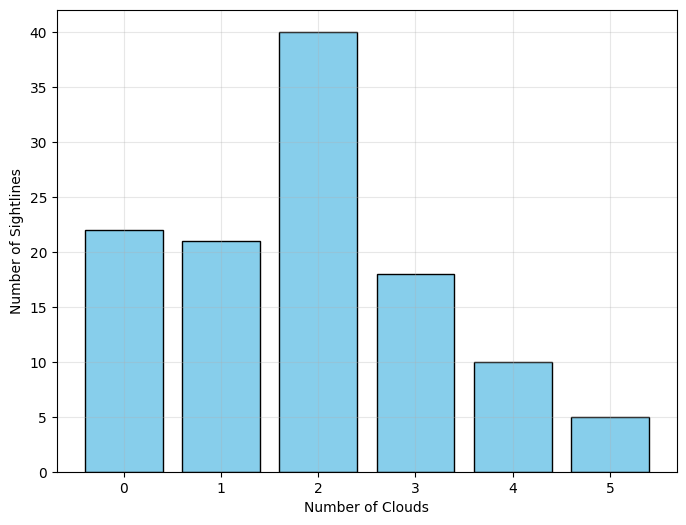

In [8]:
def column_plot(x_data, y_data, xlabel='X', ylabel='Y', title=None):
    """
    Creates a simple column/bar plot with x and y data.
    
    Parameters:
        x_data: array-like - data for x-axis
        y_data: array-like - data for y-axis
        xlabel: str - x-axis label
        ylabel: str - y-axis label
        title: str - plot title (optional)
    """
    plt.figure(figsize=(8, 6))
    plt.bar(x_data, y_data, color='skyblue', edgecolor='black')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    if title:
        plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.show()

# Example usage with some sample data:
x = np.array([0, 1, 2, 3, 4, 5])
y = np.array([22, 21, 40, 18, 10, 5])
column_plot(x, y, xlabel='Number of Clouds', ylabel='Number of Sightlines')